# Cross-method comparison: exact vs. NNQS vs. VQE

Pulls together the three methods from `01_exact_diagonalization.ipynb`, `02_nnqs.ipynb`, and `03_vqe.ipynb` onto the same figures, to see directly how they compare rather than reading three separate notebooks. Same Hamiltonian and boundary conditions throughout: open-BC TFIM, $J=1$, $h_c=1$.

Exact and NNQS cover the full grid: `L ∈ {4, 6, 8, 10, 12, 16, 20, 24}` × 21 `h`-values. VQE covers a 7-point subset of `h`, at all sizes up to `L=20` and at three `h`-values at `L=24`. Comparisons below use VQE's smaller grid as the common set.

**The VQE numbers here come from `results/vqe_seeds/`, not from a single run.** Every VQE point is repeated over 8 random initializations, because the HVA optimizer is not convex and a single run is one draw from a distribution of local minima. Near $h_c$ that distribution is bimodal — most seeds converge to a few tenths of a percent and a few fail outright at 6-8% — so these figures show the median and the interquartile range, and count how many seeds exceeded 1%. A mean and standard deviation would sit in the gap between the two groups and describe neither. `06_vqe_uncertainty.ipynb` works through that in detail.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np

# results/exact/ also holds L=2, the hardware track's reference value. It is not
# a simulation-track size, so it is kept out of everything above the L=2 section.
SIM_TRACK_MIN_L = 4

# The depth all the cross-method figures use. VQE's other depths are a scan over
# L=20 only, which 03_vqe.ipynb covers.
VQE_LAYERS = 10


def load_records(method_dir):
    """Load every {L}/{h}.json under a results directory, skipping L=2."""
    records = []
    for L_dir in sorted(method_dir.glob("*"), key=lambda p: int(p.name)):
        if int(L_dir.name) < SIM_TRACK_MIN_L:
            continue
        for f in sorted(L_dir.glob("*.json")):
            records.append(json.loads(f.read_text()))
    return records


def load_vqe_seeds(summary_path, n_layers=VQE_LAYERS):
    """Load the VQE seed ensemble, one record per (L, h) at a fixed depth.

    Each record carries the median over seeds plus the quartiles and a count of
    seeds that missed 1%, rather than a single energy — see this notebook's
    opening cell for why the median rather than the mean.
    """
    summary = json.loads(summary_path.read_text())
    records = []
    for entry in summary.values():
        if entry["n_layers"] != n_layers:
            continue
        records.append({
            "L": entry["L"],
            "h": entry["h"],
            "n_layers": entry["n_layers"],
            "E0": entry["E0"]["median"],
            "E0_q1": entry["E0"]["q1"],
            "E0_q3": entry["E0"]["q3"],
            "rel_error": entry["rel_error"]["median"],
            "rel_error_q1": entry["rel_error"]["q1"],
            "rel_error_q3": entry["rel_error"]["q3"],
            "wall_time_s": entry["wall_time_s"]["median"],
            "n_seeds": entry["rel_error"]["n"],
            "n_above_1pct": entry["n_above_1pct"],
        })
    return sorted(records, key=lambda r: (r["L"], r["h"]))


exact = load_records(REPO_ROOT / "results" / "exact")
nnqs = load_records(REPO_ROOT / "results" / "nnqs")
vqe = load_vqe_seeds(REPO_ROOT / "results" / "vqe_seeds" / "summary.json")

vqe_h_values = sorted({r["h"] for r in vqe})
vqe_L_values = sorted({r["L"] for r in vqe})
n_runs = sum(r["n_seeds"] for r in vqe)
print(f"exact: {len(exact)} points, nnqs: {len(nnqs)} points")
print(f"vqe: {len(vqe)} configurations at {VQE_LAYERS} layers, {n_runs} runs total")
print(f"VQE's h-grid (the common subset used below): {vqe_h_values}")
print(f"VQE's L values: {vqe_L_values}")

exact: 168 points, nnqs: 168 points
vqe: 52 configurations at 10 layers, 416 runs total
VQE's h-grid (the common subset used below): [0.4, 0.8, 0.95, 1.0, 1.05, 1.2, 1.6]
VQE's L values: [4, 6, 8, 10, 12, 16, 20, 24]


## Ground-state energy vs. h, all three methods

Exact as a continuous line (its full 21-point grid), NNQS as dense markers (also its full grid — should sit right on the exact line), VQE as sparser markers (its 7-point grid) at two representative sizes: `L=8` and `L=20`. VQE's markers are the median over 8 seeds, with a bar spanning the interquartile range.

`L=8` is small enough to look like the panel where everything agrees, and it isn't. It is the first size where VQE's ferromagnetic error shows, with all 8 seeds above 1% at `h=0.4`.

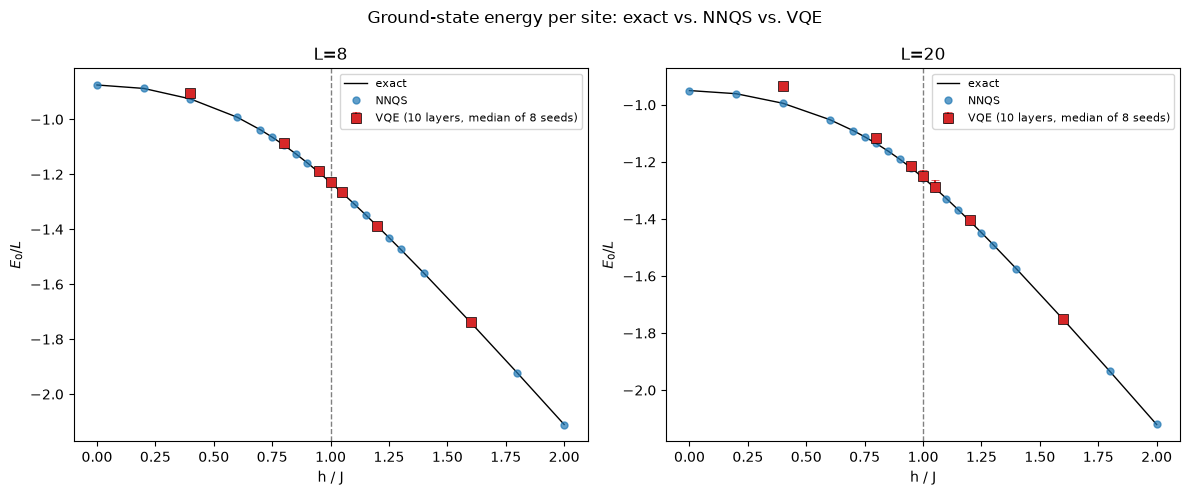

In [2]:
def energy_per_site(records, L):
    """Return (h array, E0/L array) for one system size, sorted by h."""
    pts = sorted((r["h"], r["E0"]) for r in records if r["L"] == L)
    h_arr, e_arr = map(np.array, zip(*pts))
    return h_arr, e_arr / L


def vqe_energy_per_site(records, L):
    """Same, plus the asymmetric IQR bar the seed ensemble needs."""
    pts = sorted((r["h"], r["E0"], r["E0_q1"], r["E0_q3"]) for r in records if r["L"] == L)
    h_arr, e_arr, q1, q3 = map(np.array, zip(*pts))
    # errorbar wants distances from the point, not absolute positions
    yerr = np.vstack([(e_arr - q1) / L, (q3 - e_arr) / L])
    return h_arr, e_arr / L, yerr


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, L in zip(axes, (8, 20)):
    h_e, e_e = energy_per_site(exact, L)
    h_n, e_n = energy_per_site(nnqs, L)
    h_v, e_v, v_err = vqe_energy_per_site(vqe, L)

    ax.plot(h_e, e_e, "-", color="black", linewidth=1, label="exact")
    ax.plot(h_n, e_n, "o", color="tab:blue", markersize=5, alpha=0.7, label="NNQS")
    ax.errorbar(h_v, e_v, yerr=v_err, fmt="s", color="tab:red", markersize=7,
                markeredgecolor="black", markeredgewidth=0.5, capsize=3,
                label=f"VQE ({VQE_LAYERS} layers, median of 8 seeds)")
    ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("h / J")
    ax.set_ylabel("$E_0 / L$")
    ax.set_title(f"L={L}")
    ax.legend(fontsize=8)

fig.suptitle("Ground-state energy per site: exact vs. NNQS vs. VQE")
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_energy_vs_h.png", dpi=150)
plt.show()

VQE separates from the exact line at low `h` and sits on it everywhere else, at both sizes. At `L=20` the gap in $E_0/L$ is 0.061 at `h=0.4` and 0.021 at `h=0.8`, then falls to 0.007 by `h=0.95` and 0.0005 at `h=1.6`. The same shape is already present at `L=8`, just smaller.

So the degradation is a ferromagnetic-phase effect that grows with `L`, not an `L=20` effect that spreads across the range — near and above $h_c$, VQE's median tracks exact at every size tested. NNQS stays on the line throughout.

## Relative error vs. system size

How does each method's accuracy hold up as `L` grows? Two panels, because the answer depends on which phase you look at, and neither panel is the critical point.

$h_c$ is where the gap closes, so it should be the hard place for both methods. It is the hard place for neither. NNQS's worst error is at `h < 1` at every single `L`, and VQE's worst is at `h=0.4` at 7 of the 8 sizes. `h=0.4`, deep in the ferromagnetic phase, is the panel where something actually happens; `h=1.0` is shown alongside it for contrast.

Log scale. The shaded band is VQE's interquartile range over 8 seeds; hollow markers flag configurations where at least one seed missed 1%.

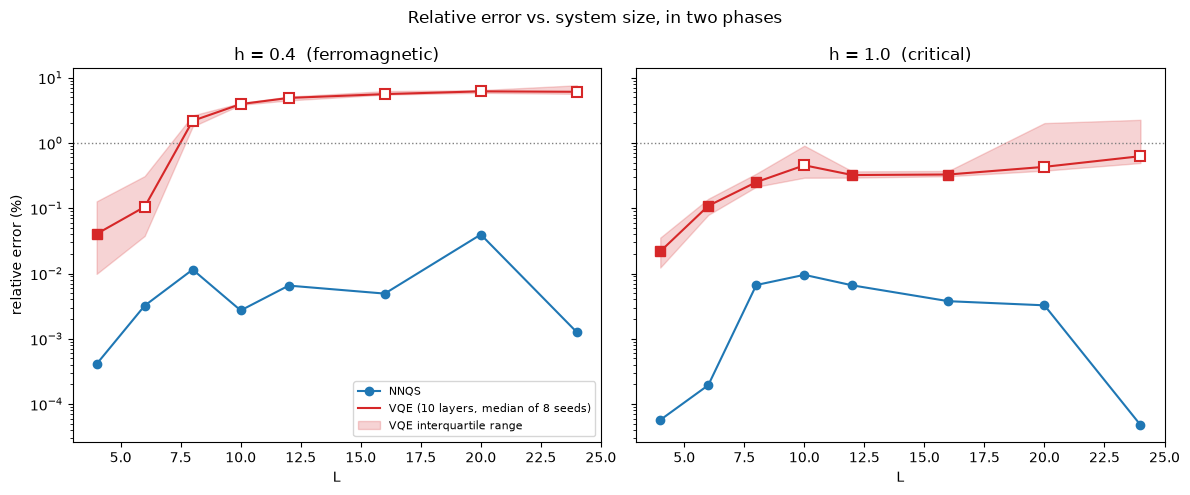

In [3]:
def error_vs_L(records, h_target=1.0):
    """Return (L array, relative-error array) at one h, sorted by L."""
    pts = sorted((r["L"], r["rel_error"]) for r in records if abs(r["h"] - h_target) < 1e-6)
    return map(np.array, zip(*pts))


def vqe_error_vs_L(records, h_target=1.0):
    """Same, plus the IQR band and the per-point count of seeds over 1%."""
    pts = sorted(
        (r["L"], r["rel_error"], r["rel_error_q1"], r["rel_error_q3"], r["n_above_1pct"])
        for r in records if abs(r["h"] - h_target) < 1e-6
    )
    return map(np.array, zip(*pts))


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, h_target in zip(axes, (0.4, 1.0)):
    L_n, err_n = error_vs_L(nnqs, h_target)
    L_v, err_v, q1_v, q3_v, fails = vqe_error_vs_L(vqe, h_target)

    ax.plot(L_n, err_n * 100, "o-", color="tab:blue", label="NNQS")
    ax.plot(L_v, err_v * 100, "-", color="tab:red",
            label=f"VQE ({VQE_LAYERS} layers, median of 8 seeds)")
    ax.fill_between(L_v, q1_v * 100, q3_v * 100, color="tab:red", alpha=0.2,
                    label="VQE interquartile range")
    # Hollow where the seeds disagree about whether the run worked at all.
    clean = fails == 0
    ax.plot(L_v[clean], err_v[clean] * 100, "s", color="tab:red", markersize=7)
    ax.plot(L_v[~clean], err_v[~clean] * 100, "s", markersize=7,
            markerfacecolor="white", markeredgecolor="tab:red", markeredgewidth=1.5)

    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_yscale("log")
    ax.set_xlabel("L")
    ax.set_title(f"h = {h_target}" + ("  (ferromagnetic)" if h_target < 1 else "  (critical)"))

axes[0].set_ylabel("relative error (%)")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("Relative error vs. system size, in two phases")
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_error_vs_L.png", dpi=150)
plt.show()

## Relative error vs. h, at L=20

Which method degrades, and where. NNQS stays under 0.05% across the whole range. VQE's median falls monotonically as `h` rises — 6.16% at `h=0.4`, 1.82% at `h=0.8`, then 0.56%, 0.43%, 0.26%, 0.15% and 0.03% across the rest. Only the two ferromagnetic points exceed 1%.

The hollow markers matter more than the line here. At `h` between 0.95 and 1.2 the median is fine but the seeds are split: one or two of eight land at 6-8% while the rest converge normally. Near $h_c$, `L=20` VQE is a reliability problem, not an accuracy one.

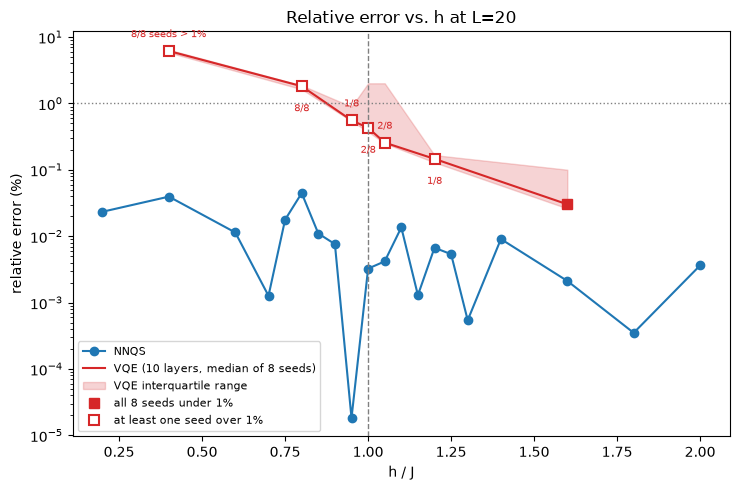

In [4]:
def error_vs_h(records, L=20):
    """Return (h array, relative-error array) for one system size, sorted by h.

    h=0 is dropped. There the RBM represents the ground state exactly, so its
    error is machine zero — it carries no information and on a log axis it
    stretches the scale over ten extra decades.
    """
    pts = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == L and r["h"] > 0)
    return map(np.array, zip(*pts))


def vqe_error_vs_h(records, L=20):
    """Same, plus the IQR band and the per-point count of seeds over 1%."""
    pts = sorted(
        (r["h"], r["rel_error"], r["rel_error_q1"], r["rel_error_q3"], r["n_above_1pct"])
        for r in records if r["L"] == L
    )
    return map(np.array, zip(*pts))


L_plot = 20
fig, ax = plt.subplots(figsize=(7.5, 5))
h_n, err_n = error_vs_h(nnqs, L_plot)
h_v, err_v, q1_v, q3_v, fails = vqe_error_vs_h(vqe, L_plot)

ax.plot(h_n, err_n * 100, "o-", color="tab:blue", label="NNQS")
ax.plot(h_v, err_v * 100, "-", color="tab:red",
        label=f"VQE ({VQE_LAYERS} layers, median of 8 seeds)")
ax.fill_between(h_v, q1_v * 100, q3_v * 100, color="tab:red", alpha=0.2,
                label="VQE interquartile range")
clean = fails == 0
ax.plot(h_v[clean], err_v[clean] * 100, "s", color="tab:red", markersize=7,
        label="all 8 seeds under 1%")
ax.plot(h_v[~clean], err_v[~clean] * 100, "s", markersize=7, markerfacecolor="white",
        markeredgecolor="tab:red", markeredgewidth=1.5, label="at least one seed over 1%")
# Alternate the label offset so the closely spaced near-critical points don't collide.
for i, (h, err, n) in enumerate(zip(h_v[~clean], err_v[~clean], fails[~clean])):
    ax.annotate(f"{n}/8 seeds > 1%" if i == 0 else f"{n}/8", (h, err * 100),
                textcoords="offset points", xytext=(0, -18 if i % 2 else 10),
                ha="center", fontsize=7, color="tab:red")

ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("h / J")
ax.set_ylabel("relative error (%)")
ax.set_title(f"Relative error vs. h at L={L_plot}")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_error_vs_h_L20.png", dpi=150)
plt.show()

## Cost comparison

Wall-clock time per point at `h=1.0`, log scale. VQE's time is the median over its 8 seeds.

Exact diagonalization scales the worst — it is exponential in `L`, and the other two are not — but "worst asymptotically" and "slowest here" are different statements. Exact is in fact the *cheapest* method at every size up to `L=20`, and only crosses NNQS between `L=20` and `L=24`.

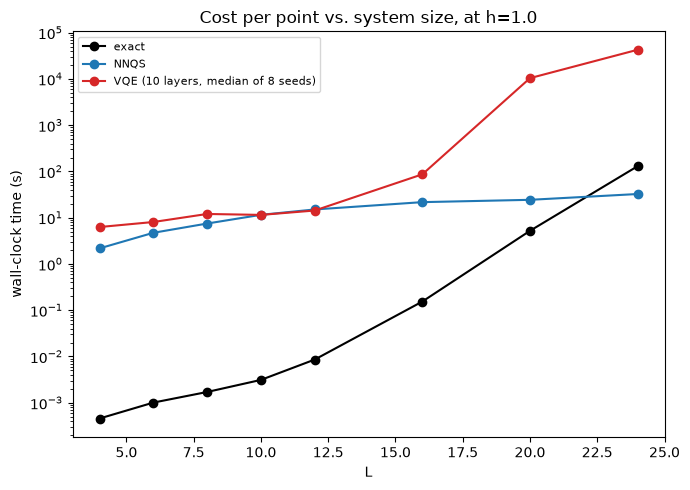

In [5]:
def time_vs_L(records, h_target=1.0):
    """Return (L array, wall-clock seconds) at one h, sorted by L."""
    pts = sorted((r["L"], r["wall_time_s"]) for r in records if abs(r["h"] - h_target) < 1e-6)
    return map(np.array, zip(*pts))


fig, ax = plt.subplots(figsize=(7, 5))
for records, color, label in [(exact, "black", "exact"), (nnqs, "tab:blue", "NNQS"),
                              (vqe, "tab:red", f"VQE ({VQE_LAYERS} layers, median of 8 seeds)")]:
    L_arr, t_arr = time_vs_L(records)
    ax.plot(L_arr, t_arr, "o-", color=color, label=label)

ax.set_yscale("log")
ax.set_xlabel("L")
ax.set_ylabel("wall-clock time (s)")
ax.set_title("Cost per point vs. system size, at h=1.0")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_cost_vs_L.png", dpi=150)
plt.show()

NNQS is the clear winner across this whole range. It matches exact to within 0.12% at its single worst point (`L=24`, `h=0.6`) and to under 0.05% at the other 167, and it does it at a small fraction of VQE's cost — at `L=20`, `h=1.0`, NNQS takes 24.4 s against a VQE 8-seed median of 10,405 s, or 2.9 hours. That is 0.23% of the cost, and the gap widens at `L=24`.

VQE's 10-layer HVA is competitive at small `L` and in the paramagnetic phase, and falls behind in the ferromagnetic phase as `L` grows. More circuit depth helps there and only there: at `L=20`, `h=0.4`, going from 10 to 30 layers moves the median from 6.16% to 2.59%, a 6.3σ shift on the seed spread — but it never reaches 1% at any depth tested. Near $h_c$ depth changes nothing, because nothing there is broken: the converged seeds are already at a few tenths of a percent at 10 layers, and what added depth would need to fix is how often a run fails, not how accurate a successful one is. `06_vqe_uncertainty.ipynb` has the depth scan.

The real value of the VQE track isn't beating NNQS in simulation — it's that VQE, unlike NNQS, is a method a real quantum computer can run, which is what Phase 3 (MonarQ hardware) tests directly.

## Hardware track: exact vs. NNQS vs. VQE-sim vs. real MonarQ hardware

The roadmap's original headline figure — all methods overlaid, including VQE on real hardware — was only ever going to be possible at whatever size real hardware noise still leaves a signal. `notebooks/05_monarq_hardware.ipynb` settled on `L=2` at `n_layers=1`, the shallowest point on the ladder.

The reason is depth, not qubit count. At one layer the wider registers do better, not worse: `L=2` retains 29.4% of the energy signal, `L=4` retains 36.6% and `L=6` retains 33.4%. What orders the damage is two-qubit gates *per qubit*, $4(L-1)n/L$ — each IsingZZ becomes 2 native CZ shared across `L` qubits — which grows without bound in depth but saturates towards $4n$ in `L`.

The largest single effect in the hardware track is neither. It is which physical qubits the circuit lands on: the same circuit retains 17-35% on the pair the plugin picks by default and 53-64% on qubits 13-10. Both placements are plotted below.

`L=2` isn't part of the classical simulation-track grid, so NNQS and VQE-sim are computed fresh here at the same three `h`-values used for the hardware submission. The exact reference is read from `results/exact/2/`, which is archived for this purpose and matches the closed form $E_0 = -\sqrt{J^2 + 4h^2}$.

∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

  0%|          | 0/300 [00:00<?, ?it/s]

/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, v

  0%|          | 0/300 [00:00<?, ?it/s]

/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, v

  0%|          | 0/300 [00:00<?, ?it/s]

hardware repeats per h: {0.4: 7, 1.0: 7, 1.6: 7}
  h=0.4: default -0.217 +/- 0.023   best placement -0.684 +/- 0.019   exact -1.281
  h=1.0: default -0.657 +/- 0.041   best placement -1.401 +/- 0.031   exact -2.236
  h=1.6: default -1.157 +/- 0.067   best placement -2.158 +/- 0.030   exact -3.353


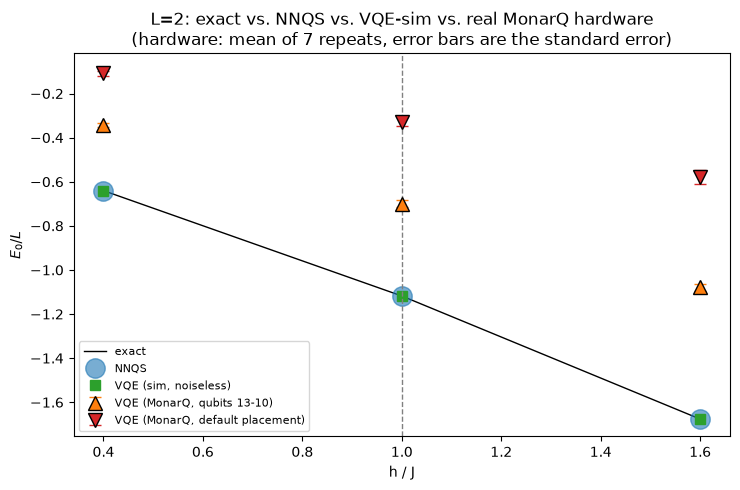

In [6]:
from collections import defaultdict

from src.nnqs import train_nnqs
from src.vqe import train_vqe

L = 2
n_layers = 1
h_values = (0.4, 1.0, 1.6)

exact_dir_L2 = REPO_ROOT / "results" / "exact" / str(L)
exact_L2 = {h: json.loads((exact_dir_L2 / f"{h:.3f}.json").read_text())["E0"] for h in h_values}
nnqs_L2 = {h: train_nnqs(L=L, h=h, J=1.0, alpha=2, n_samples=1024, n_iter=300, learning_rate=0.02, diag_shift=0.01, seed=0)[0] for h in h_values}
vqe_sim_L2 = {h: train_vqe(L=L, h=h, J=1.0, n_layers=n_layers, n_steps=600, stepsize=0.1, seed=0)[0] for h in h_values}


def load_hardware_repeats(arm):
    """Mean and standard error of the repeated 1-layer hardware runs, per h.

    results/vqe_hardware/2/ holds several kinds of file — calibration dumps,
    Bloch-vector measurements, the coupler scan, and runs at 1, 2 and 4 layers
    across two qubit placements. Only the repeated 1-layer runs for one
    placement belong on this figure, so the glob is narrow on purpose. A bare
    *.json glob mixes all of it together and picks up files with no E0 field.
    """
    reps = defaultdict(list)
    for f in sorted((REPO_ROOT / "results" / "vqe_hardware" / str(L)).glob(f"*_layers1_rep*_{arm}.json")):
        r = json.loads(f.read_text())
        reps[r["h"]].append(r["E0"])
    mean = {h: np.mean(v) for h, v in reps.items()}
    sem = {h: np.std(v, ddof=1) / np.sqrt(len(v)) for h, v in reps.items()}
    n = {h: len(v) for h, v in reps.items()}
    return mean, sem, n


hw_default, hw_default_sem, hw_n = load_hardware_repeats("default")
hw_best, hw_best_sem, _ = load_hardware_repeats("best")
print(f"hardware repeats per h: {dict(sorted(hw_n.items()))}")
for h in h_values:
    print(f"  h={h}: default {hw_default[h]:.3f} +/- {hw_default_sem[h]:.3f}   "
          f"best placement {hw_best[h]:.3f} +/- {hw_best_sem[h]:.3f}   exact {exact_L2[h]:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 5))
h_arr = np.array(h_values)
ax.plot(h_arr, [exact_L2[h] / L for h in h_values], "-", color="black", linewidth=1, label="exact")
# NNQS and noiseless VQE both land on the exact line at L=2, so draw NNQS as a
# larger marker underneath rather than have one hide the other completely.
ax.plot(h_arr, [nnqs_L2[h] / L for h in h_values], "o", color="tab:blue",
        markersize=14, alpha=0.6, label="NNQS")
ax.plot(h_arr, [vqe_sim_L2[h] / L for h in h_values], "s", color="tab:green",
        markersize=7, label="VQE (sim, noiseless)")
ax.errorbar(h_arr, [hw_best[h] / L for h in h_values],
            yerr=[hw_best_sem[h] / L for h in h_values],
            fmt="^", color="tab:orange", markersize=10, markeredgecolor="black",
            capsize=4, label="VQE (MonarQ, qubits 13-10)")
ax.errorbar(h_arr, [hw_default[h] / L for h in h_values],
            yerr=[hw_default_sem[h] / L for h in h_values],
            fmt="v", color="tab:red", markersize=10, markeredgecolor="black",
            capsize=4, label="VQE (MonarQ, default placement)")

ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("h / J")
ax.set_ylabel("$E_0 / L$")
ax.set_title("L=2: exact vs. NNQS vs. VQE-sim vs. real MonarQ hardware\n(hardware: mean of 7 repeats, error bars are the standard error)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_hardware_L2.png", dpi=150)
plt.show()

Exact, NNQS, and noiseless VQE-sim sit on top of each other — `L=2` is trivially easy for every classical and noiseless method, and the noiseless VQE is exact to about 1e-16 here. So the whole distance from the black line is device noise, with no algorithmic error mixed in.

Real hardware is well off the line at every `h`, on both placements. The distance between the orange and red series is the placement effect: the same trained circuit, transpiled identically, differing only in which physical qubits it ran on. On the default pair the measured energy retains 17-35% of the exact value; on qubits 13-10 it retains 53-64%.

`L=2` separates device error from algorithmic error perfectly and samples device error badly. One qubit on this chip carries a large coherent defect, and in a two-qubit register that qubit has half the weight — which is why the wider registers above hold up better. The plotted points are 7 repeats each. The three single-shot values originally archived here are unrepeated measurements carrying no uncertainty, and all three sit lower than the repeat means, so they are not plotted. `05_monarq_hardware.ipynb` quantifies all of this.